# Пятая лабораторная работа

## Установка и импорт необходимых библиотек

In [9]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

Загрузка и подготовка данных

In [11]:
df = pd.read_csv('cars_moldova_clean.csv', delimiter=',')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35456 entries, 0 to 35455
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Make                  35456 non-null  object 
 1   Model                 35456 non-null  object 
 2   Year                  35456 non-null  int64  
 3   Style                 35456 non-null  object 
 4   Distance              35456 non-null  float64
 5   Engine_capacity(cm3)  35456 non-null  float64
 6   Fuel_type             35456 non-null  object 
 7   Transmission          35456 non-null  int64  
 8   Price(euro)           35456 non-null  float64
 9   km_year               35456 non-null  float64
dtypes: float64(4), int64(2), object(4)
memory usage: 2.7+ MB


In [12]:
cat_columns = ['Make', 'Model', 'Style', 'Fuel_type', 'Transmission']
num_columns = ['Year', 'Distance', 'Engine_capacity(cm3)', 'Price(euro)', 'km_year']

Реализуем класс PCA.

In [13]:
class PCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.values = None
        self.mean = None
    
    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        cov_matrix = np.cov(X - self.mean, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
        idx = eigenvalues.argsort()[::-1]
        self.components = eigenvectors[:, idx][:, :self.n_components]
        self.values = eigenvalues[idx]
        return self
    
    def transform(self, X):
        X = X - self.mean
        return np.dot(X, self.components)

    def fit_transform(self, X):
        return self.fit(X).transform(X)
    
    def inverse_transform(self, X_new):
        return np.dot(X_new, self.components.T) + self.mean
    
    def score(self, X):
        SStot = np.sum(np.square(X - np.mean(X)))
        SSres = np.sum(np.square(X - self.inverse_transform(self.fit_transform(X))))
        return 1 - SSres/SStot
    
    def plot_eigvalues(self, figsize=(12,4)):
        plt.figure(figsize=figsize)
        plt.plot(self.values, '-o', label='all eigvalues')
        plt.plot(self.values[:self.n_components], '-o', label='eigen subspace')
        plt.title('Собственные значения')
        plt.legend()
        plt.show()

Применим PCA к числовым признакам.

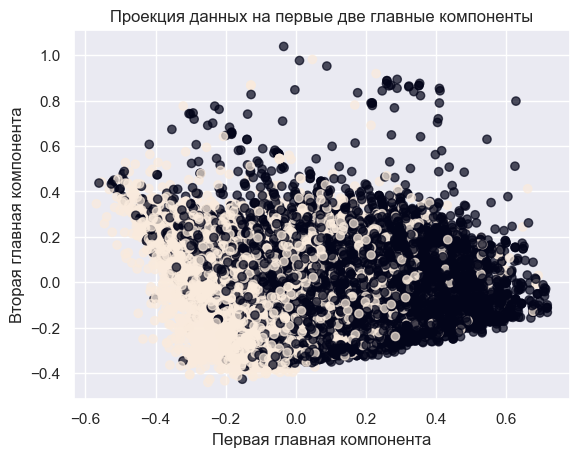

Собственные значения: [0.03897604 0.02156486 0.01695029 0.00284383 0.00168523]


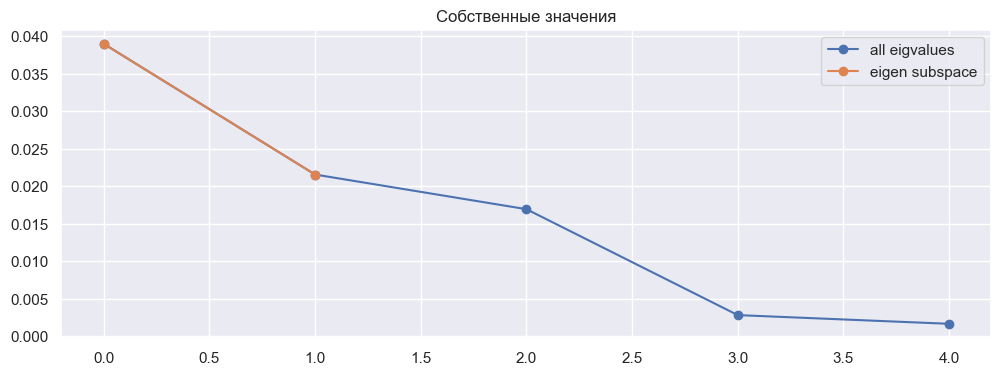

Оценка качества восстановления (R²): 0.9298345894880887


In [14]:
df_num = df[num_columns].copy()
scaler = MinMaxScaler()
X = scaler.fit_transform(df_num)

labels = df.Transmission.values

pca = PCA(n_components=2)
pca.fit(X)
X_new = pca.transform(X)

plt.scatter(X_new[:,0], X_new[:,1], c=labels, alpha=0.7)
plt.title('Проекция данных на первые две главные компоненты')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.show()

print('Собственные значения:', pca.values)
pca.plot_eigvalues()

print('Оценка качества восстановления (R²):', pca.score(X))

Визуализация весов главных компонент

<Figure size 1000x1000 with 0 Axes>

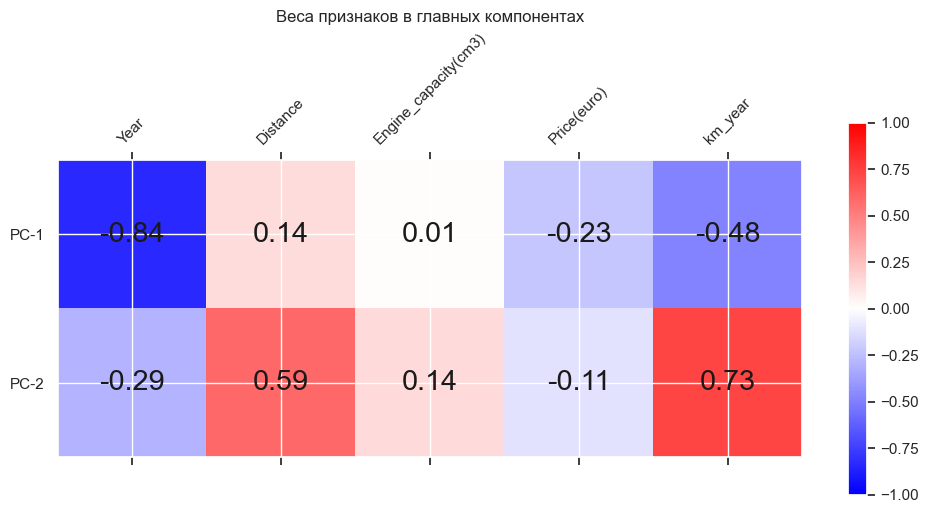

In [15]:
fig = plt.figure(figsize=(10,10))
W = pca.components.T
pca_names = ['PC-'+str(x+1) for x in range(2)]

plt.matshow(W.astype(float), cmap='bwr', vmin=-1, vmax=1)

for (i, j), z in np.ndenumerate(W):
    plt.text(j, i, '{:0.2f}'.format(z), ha='center', va='center', color='k', fontsize='xx-large')

plt.xticks(np.arange(0, W.shape[1]), df[num_columns].columns, rotation=45)
plt.yticks(np.arange(0, W.shape[0]), pca_names)
plt.colorbar()
plt.title('Веса признаков в главных компонентах')
plt.show()

## Кластеризация методом k-средних

Реализуем класс KMeans.

In [16]:
class KMeans:
    def __init__(self, n_clusters=2, centroids=None, max_iter=10, tol=0.01):
        self.n_clusters = n_clusters
        self.centroids = centroids
        self.max_iter = max_iter        
        self.tol = tol
        self.iters = None
    
    def distance(self, X1, X2):
        return np.sqrt(np.sum(np.square(X1 - X2).T, axis=0))
    
    def init_centroids(self, X):
        c_idxs = np.random.randint(0, X.shape[0], size=self.n_clusters)
        return X[c_idxs,:]
    
    def predict(self, X):
        distances = np.zeros((X.shape[0], self.n_clusters))
        for i, centr in enumerate(self.centroids):
            distances[:,i] = self.distance(centr, X)
        return np.argmin(distances, axis=1)
    
    def delta_centroids(self, old_centroids):
        return (self.distance(self.centroids, old_centroids) /
                self.distance(old_centroids, np.mean(old_centroids))).mean()
    
    def fit(self, X):
        if self.centroids is None:
            self.centroids = self.init_centroids(X)
        
        d_centrs = np.inf
        
        for i in range(self.max_iter):
            old_centroids = np.copy(self.centroids)
            cluster_label = self.predict(X)
            
            for k in range(self.n_clusters):
                c_idxs = np.flatnonzero(cluster_label==k)
                self.centroids[k] = X[c_idxs].mean(axis=0)
            
            d_centrs = self.delta_centroids(old_centroids)
            self.iters = i
            
            if d_centrs <= self.tol:
                break
                
        return self
    
    def fit_transform(self, X):
        return self.fit(X).predict(X)

Применим KMeans (2 признака)

Алгоритм сошелся за 15 итераций


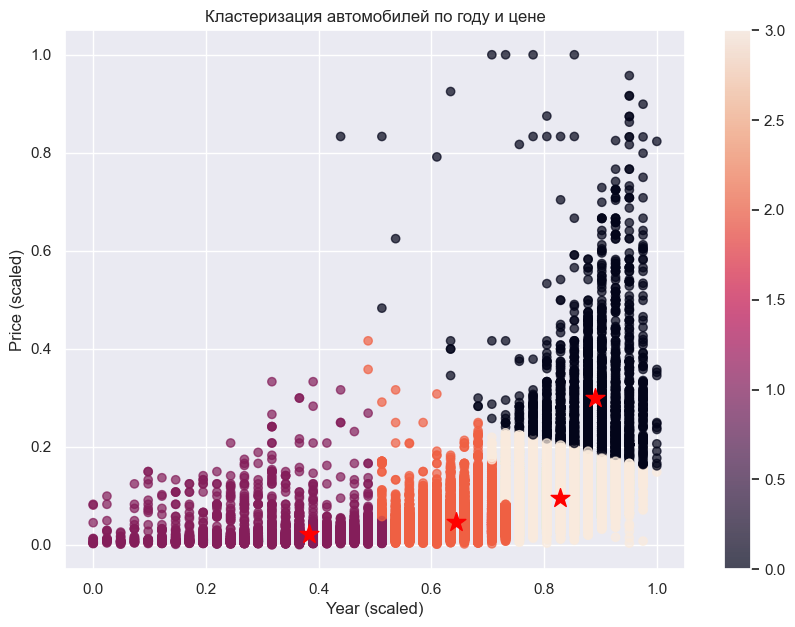

In [17]:
X_cluster = X[:,[0,3]]

kmeans = KMeans(n_clusters=4, max_iter=1000, tol=0.0001)
cluster_labels = kmeans.fit_transform(X_cluster)

print('Алгоритм сошелся за', kmeans.iters, 'итераций')

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_cluster[:, 0], X_cluster[:, 1], c=cluster_labels, alpha=0.7)
plt.scatter(kmeans.centroids[:,0], kmeans.centroids[:,1], marker='*', s=200, c='red')
plt.colorbar(scatter)
plt.xlabel('Year (scaled)')
plt.ylabel('Price (scaled)')
plt.title('Кластеризация автомобилей по году и цене')
plt.show()

Кластеризация после PCA

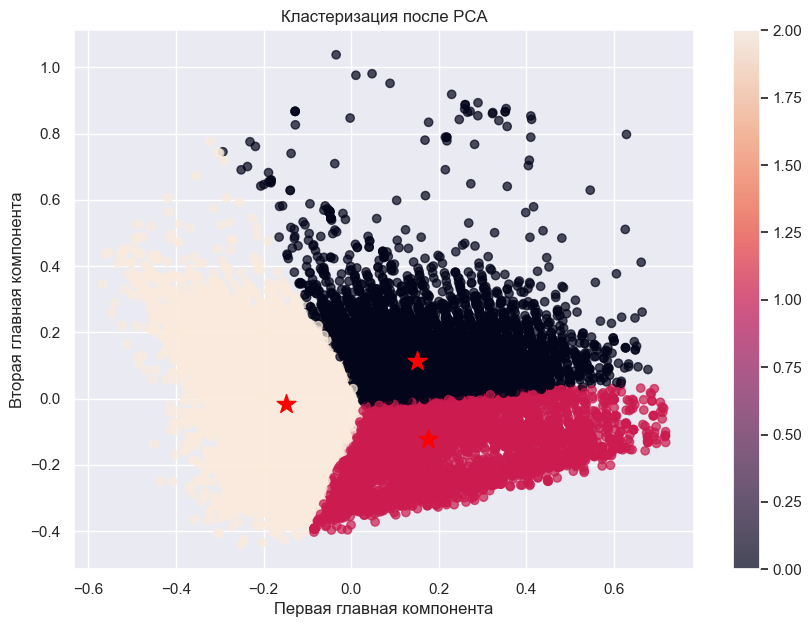

Алгоритм сошелся за 22 итераций


In [19]:
scaler = MinMaxScaler()
X_all = scaler.fit_transform(df_num)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all)

kmeans = KMeans(n_clusters=3, max_iter=1000, tol=0.00001)
cluster_labels = kmeans.fit_transform(X_pca)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, alpha=0.7)
plt.scatter(kmeans.centroids[:,0], kmeans.centroids[:,1], marker='*', s=200, c='red')
plt.colorbar(scatter)
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Кластеризация после PCA')
plt.show()

print('Алгоритм сошелся за', kmeans.iters, 'итераций')

## Контрольные вопросы

### Вопрос 1: Почему перед применением PCA необходимо масштабировать данные?

Без масштабирования признаки с большими значениями (цена) будут доминировать над признаками с малыми значениями (год), что исказит результаты PCA.

### Вопрос 2: Какой процент дисперсии объясняют первые две главные компоненты?

In [20]:
total_variance = np.sum(pca.values)
variance_ratio = pca.values[:2] / total_variance
print("Процент объясненной дисперсии первыми двумя компонентами:")
print(f"Первая компонента: {variance_ratio[0]*100:.2f}%")
print(f"Вторая компонента: {variance_ratio[1]*100:.2f}%")
print(f"Суммарно: {np.sum(variance_ratio)*100:.2f}%")

Процент объясненной дисперсии первыми двумя компонентами:
Первая компонента: 47.52%
Вторая компонента: 26.29%
Суммарно: 73.81%


### Вопрос 3: Как влияет параметр n_clusters на результаты кластеризации?

Увеличение числа кластеров даёт более детальное разбиение данных. В нашем случае оптимально 4 кластера.

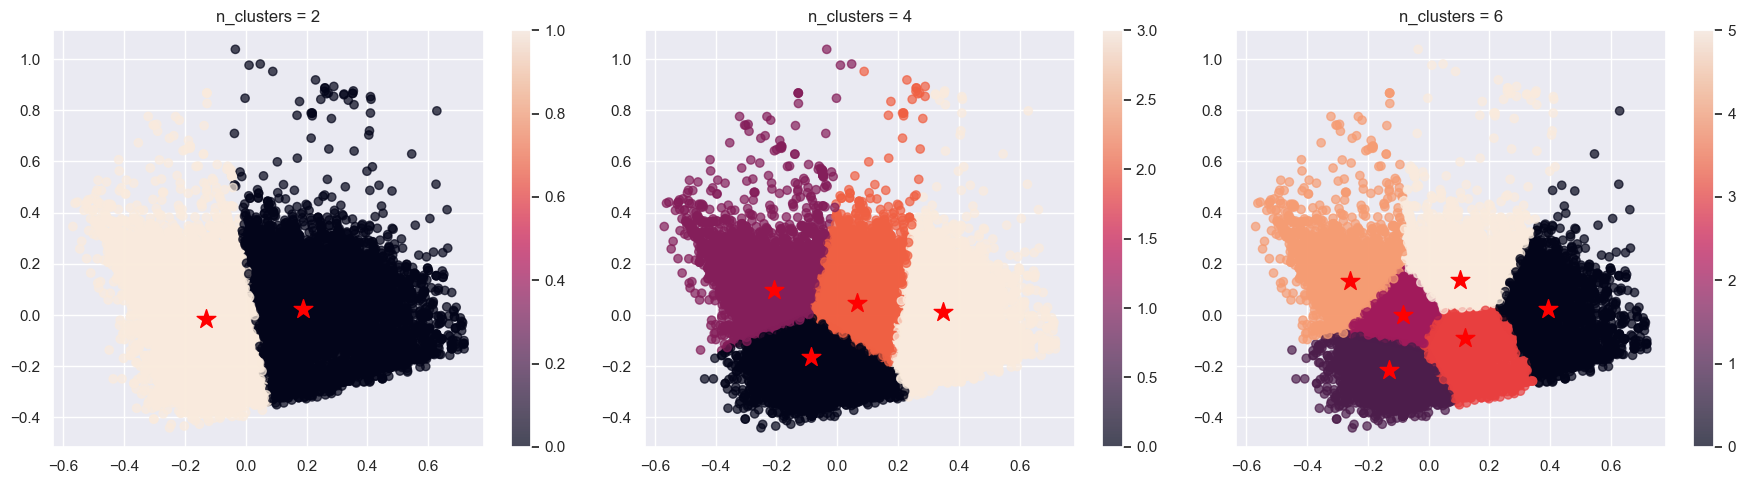

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, n_clusters in enumerate([2, 4, 6]):
    kmeans = KMeans(n_clusters=n_clusters, max_iter=1000, tol=0.0001)
    labels = kmeans.fit_transform(X_pca)
    
    scatter = axes[i].scatter(X_pca[:,0], X_pca[:,1], c=labels, alpha=0.7)
    axes[i].scatter(kmeans.centroids[:,0], kmeans.centroids[:,1], 
                   marker='*', s=200, c='red')
    axes[i].set_title(f'n_clusters = {n_clusters}')
    plt.colorbar(scatter, ax=axes[i])

plt.tight_layout()
plt.show()

### Вопрос 4: Почему полезно применять кластеризацию после PCA?

Это снижает вычислительную сложность и шум в данных, делает визуализацию нагляднее.

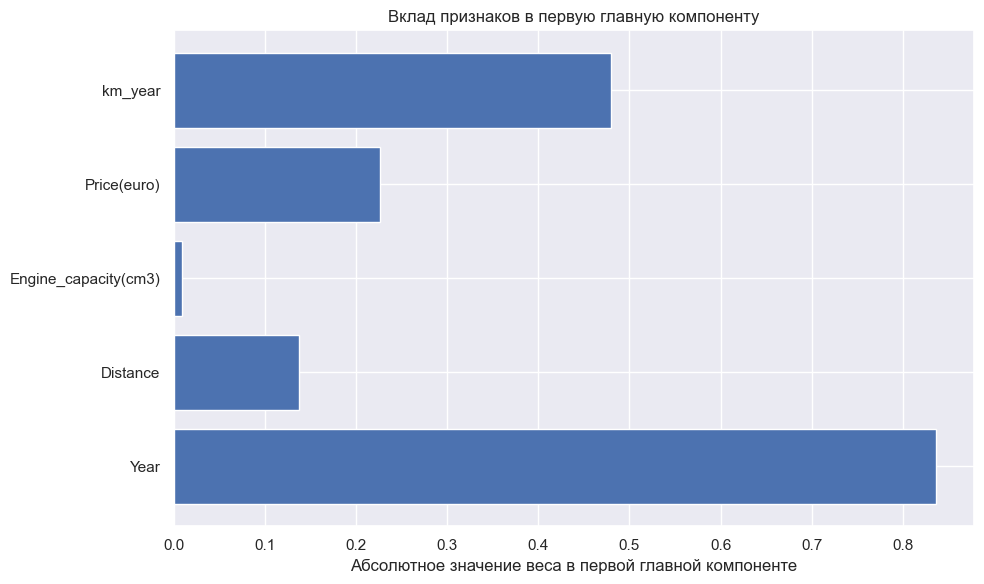

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

feature_weights = np.abs(pca.components[:, 0])
feature_names = df_num.columns

plt.figure(figsize=(10, 6))
y_pos = np.arange(len(feature_names))
plt.barh(y_pos, feature_weights)
plt.yticks(y_pos, feature_names)
plt.xlabel('Абсолютное значение веса в первой главной компоненте')
plt.title('Вклад признаков в первую главную компоненту')
plt.tight_layout()
plt.show()

### Вопрос 5: Какие признаки вносят наибольший вклад в первую главную компоненту?

Наибольший вклад вносят цена и год выпуска.